Load Data


In [2]:
import pandas as pd

prices = pd.read_csv("prices.txt", sep=r"\s+")


Price by Day

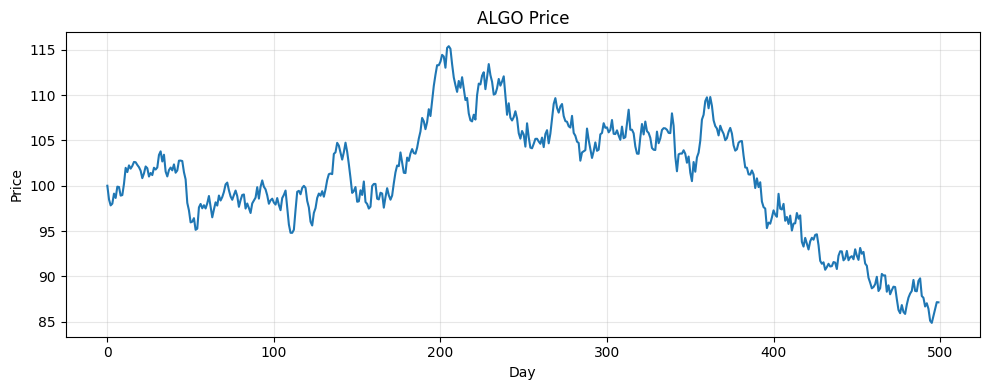

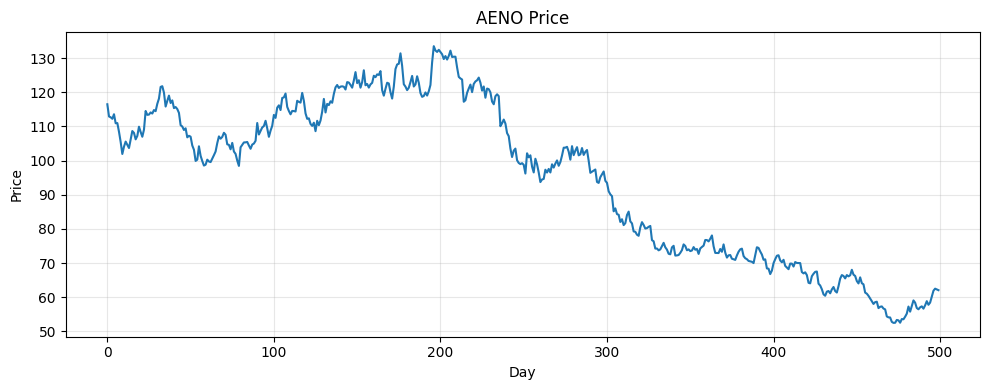

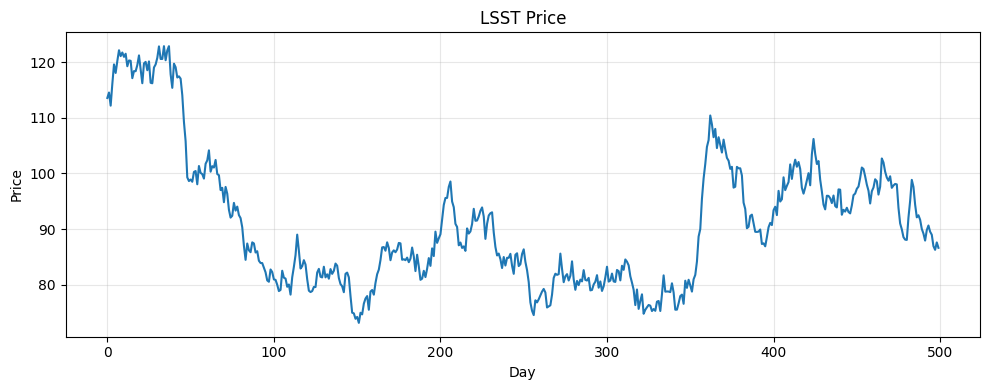

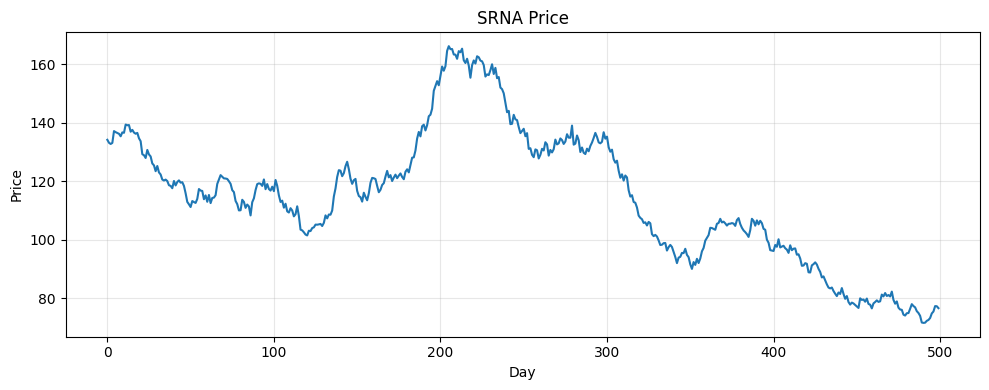

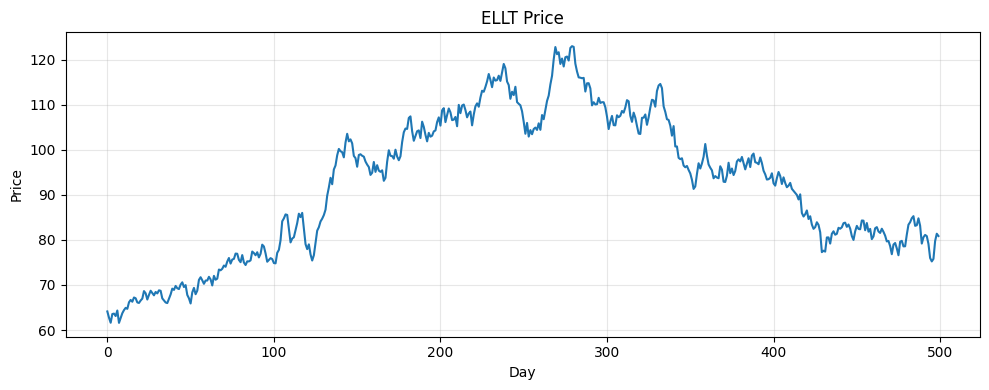

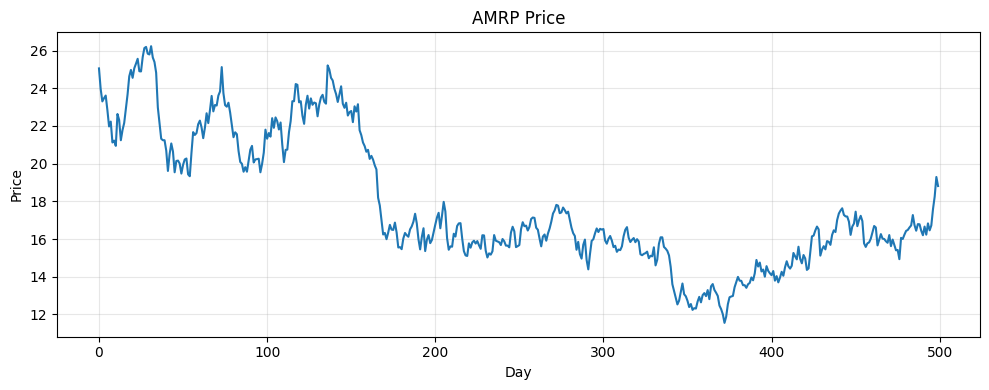

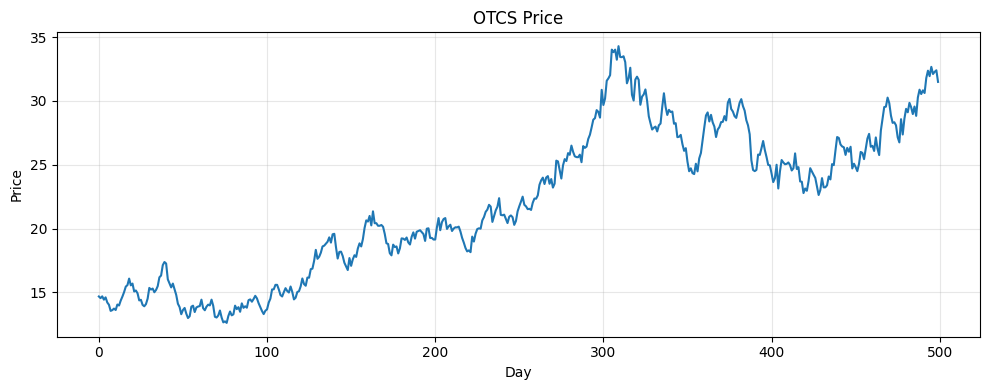

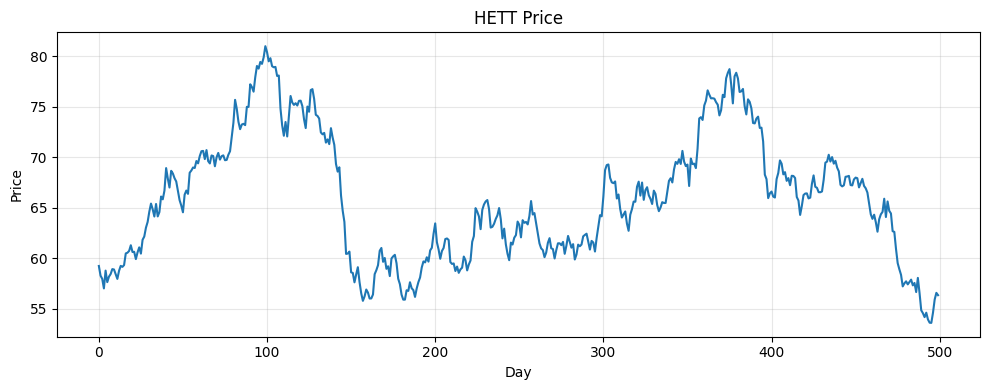

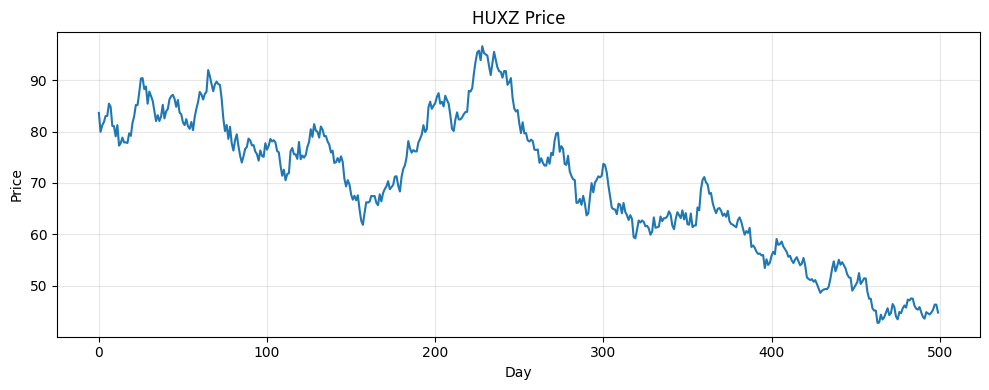

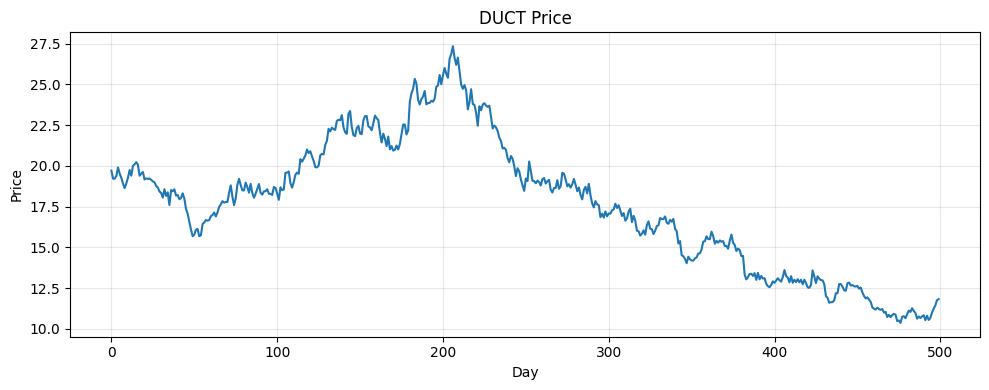

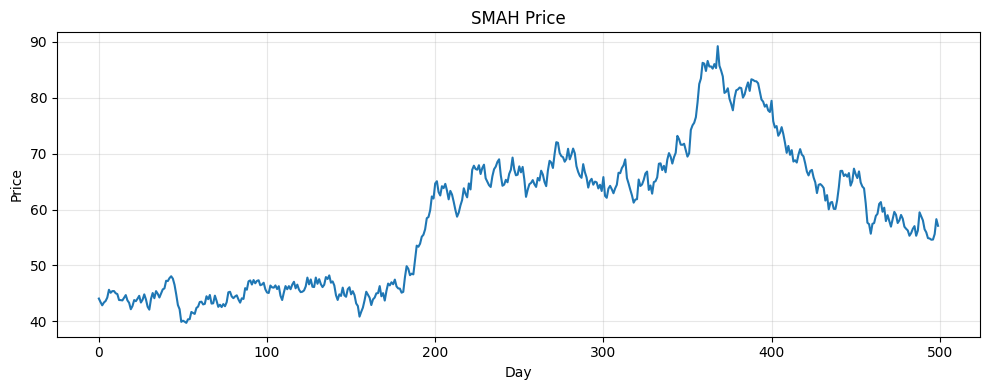

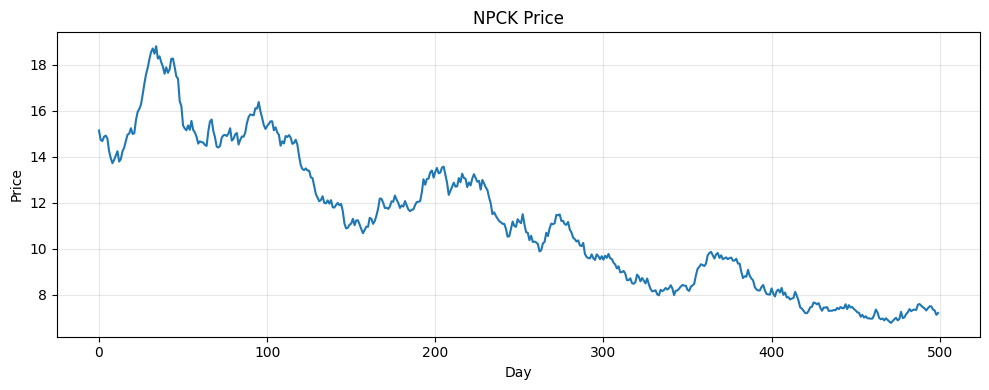

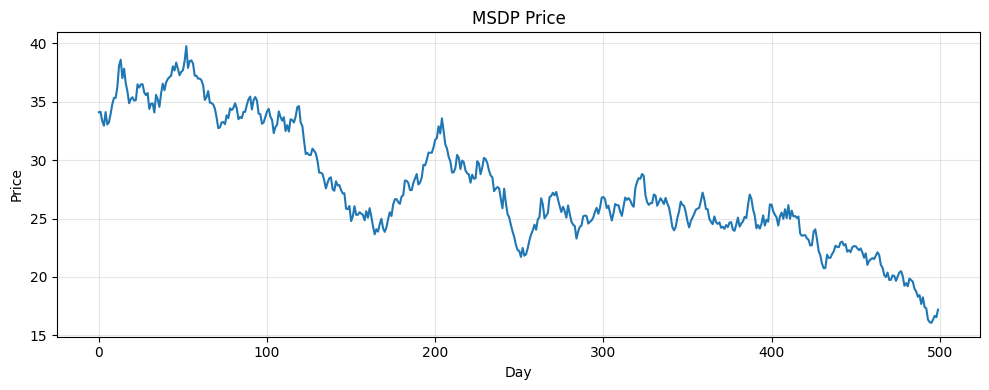

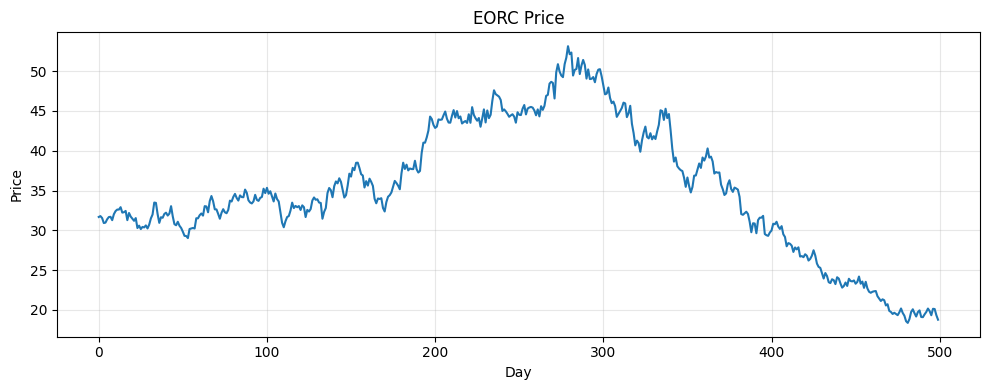

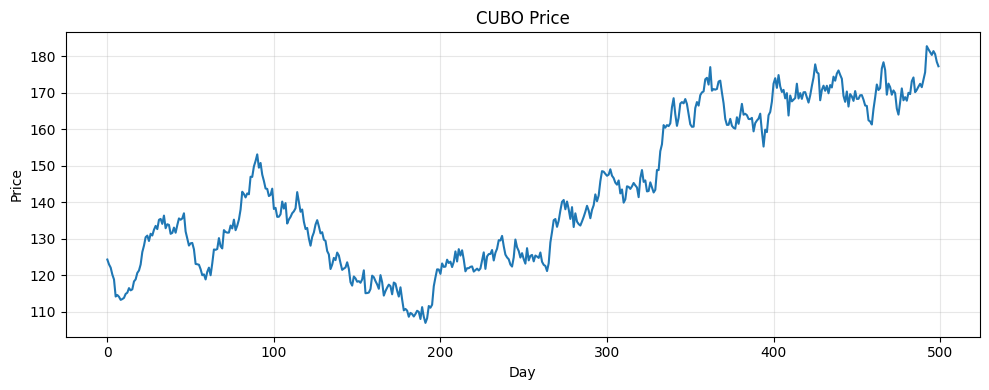

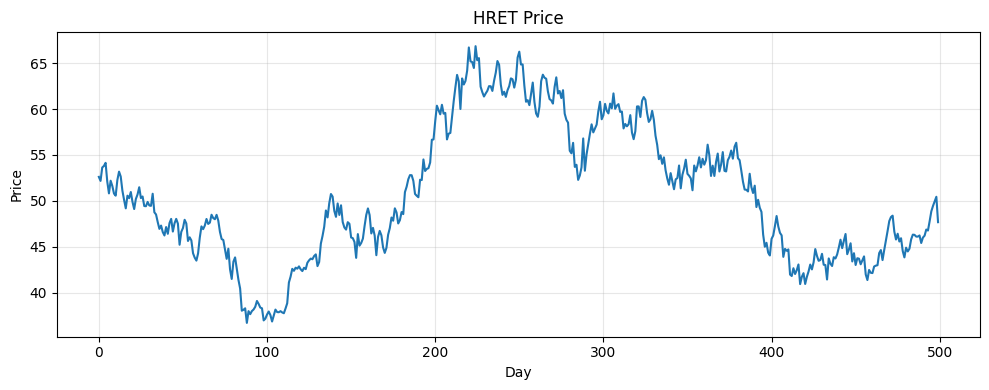

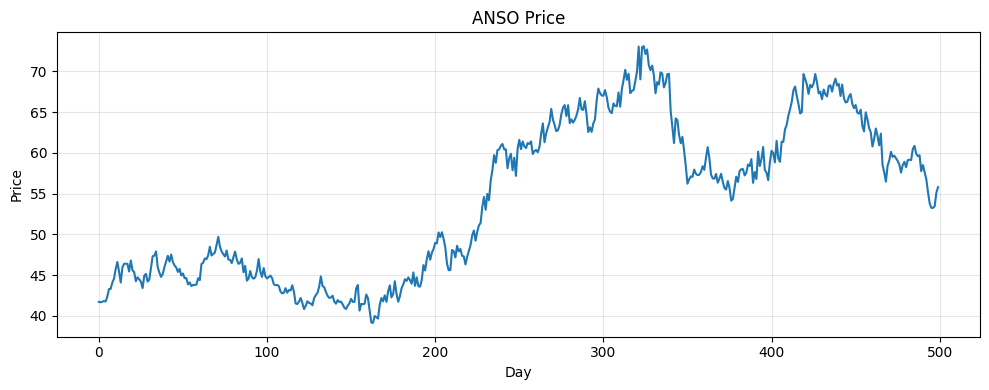

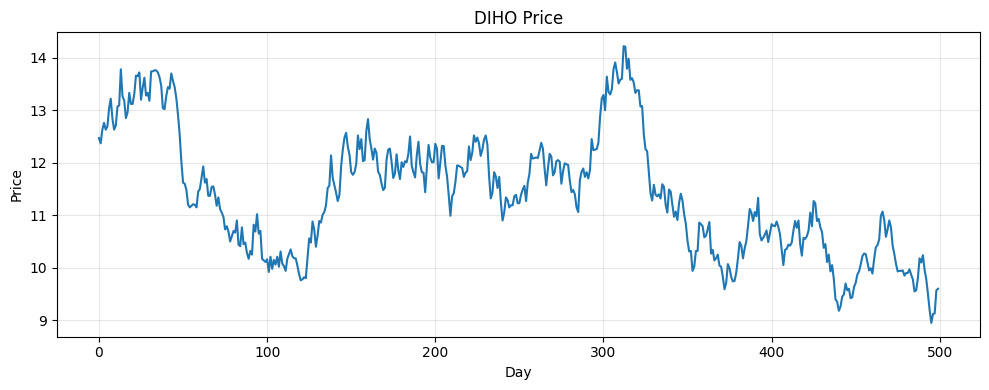

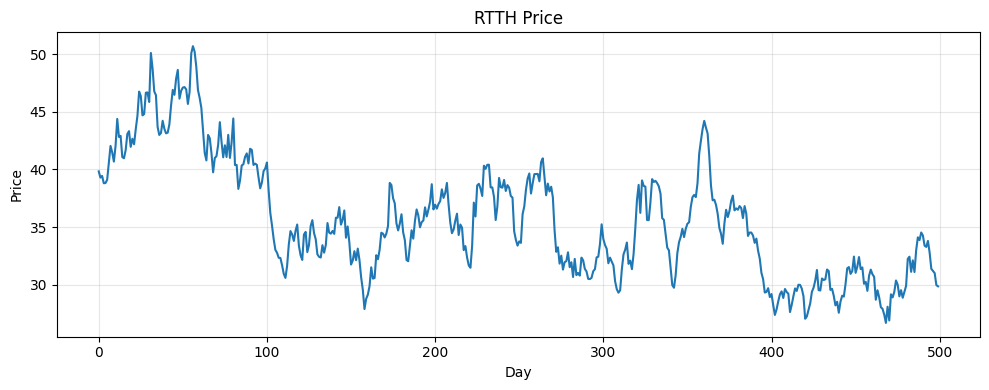

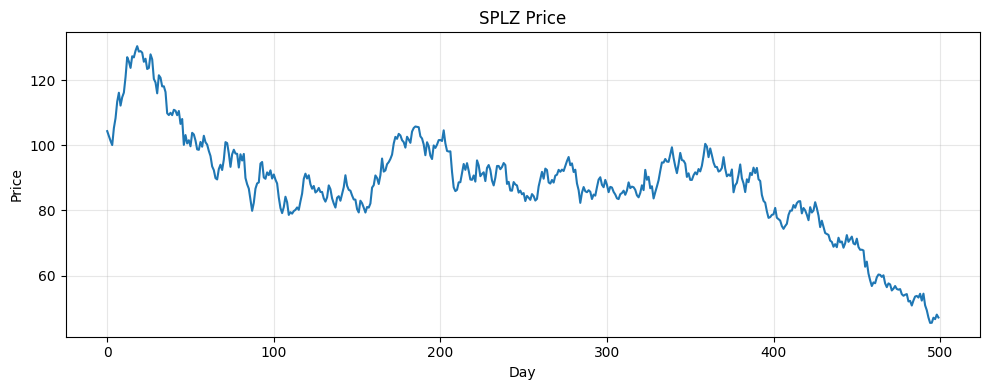

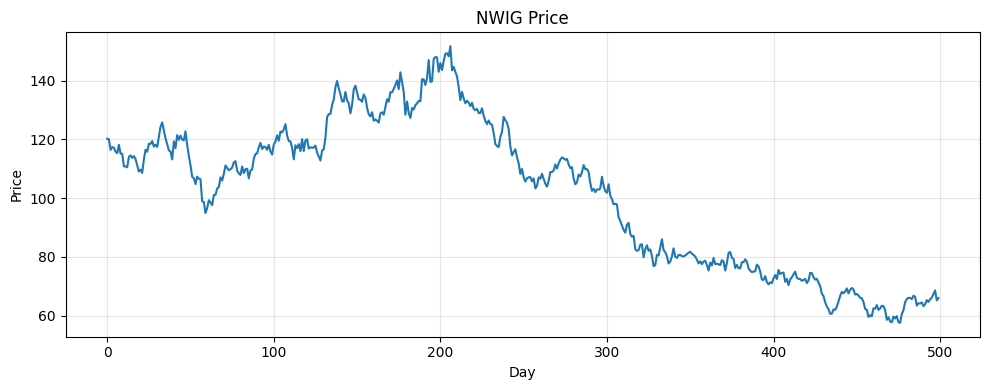

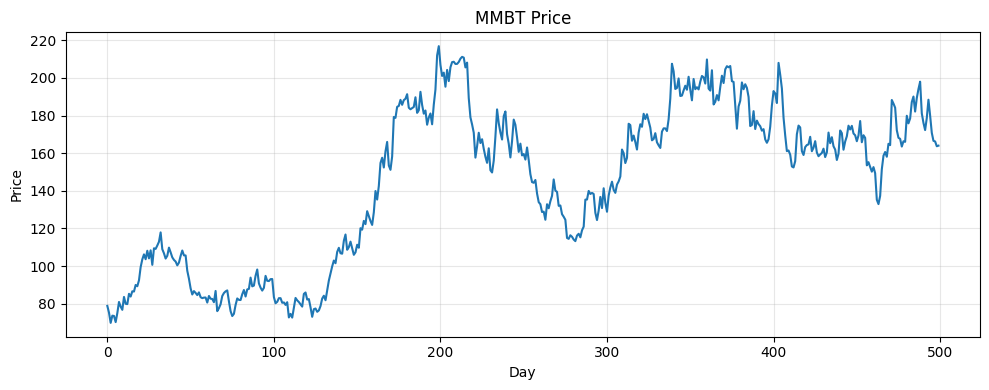

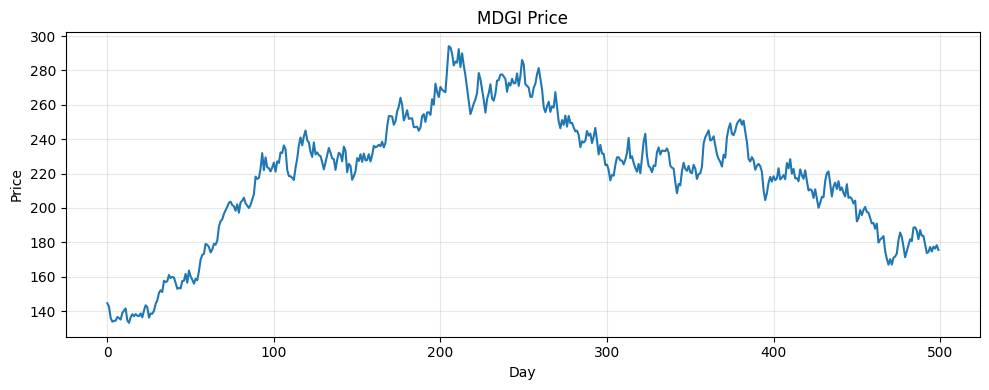

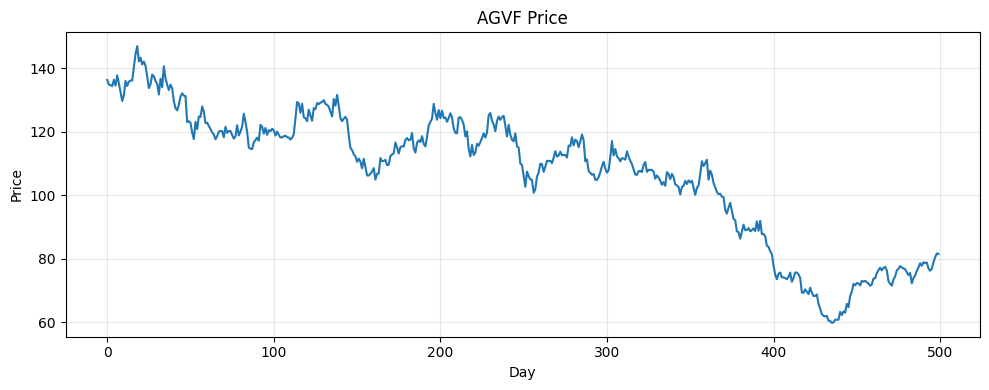

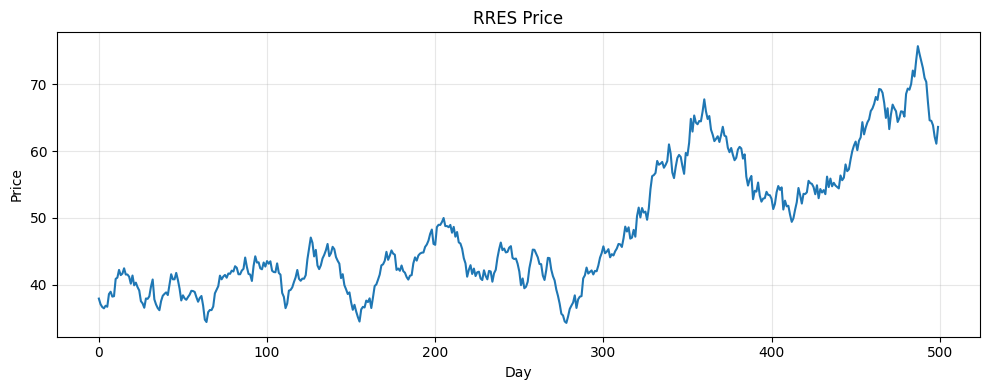

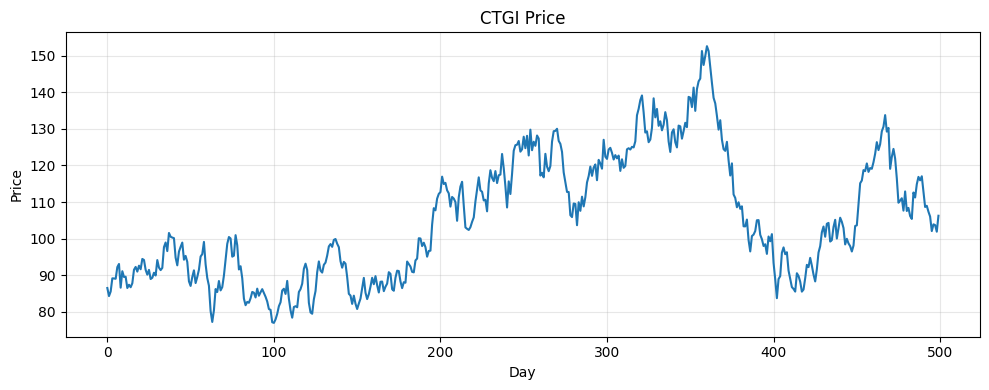

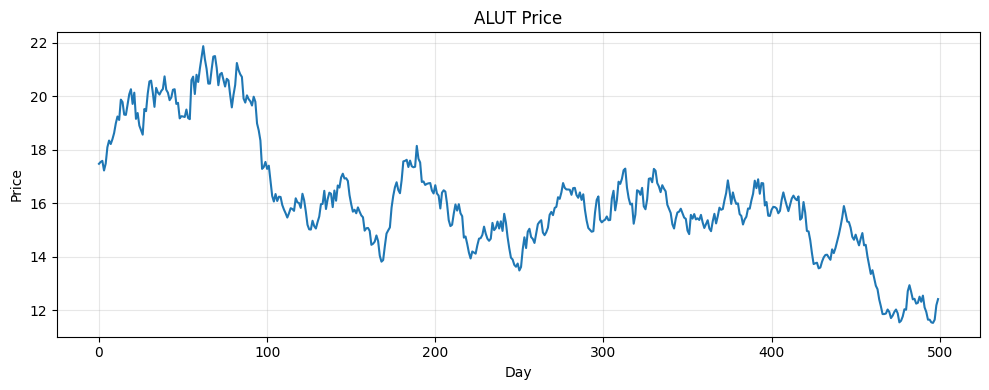

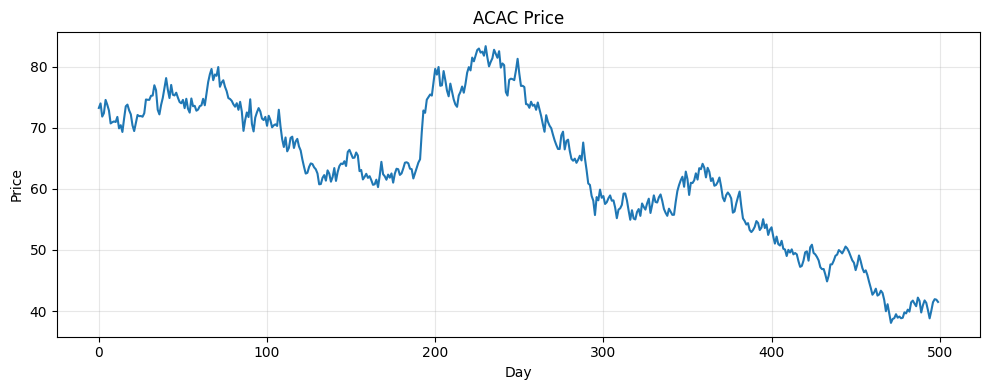

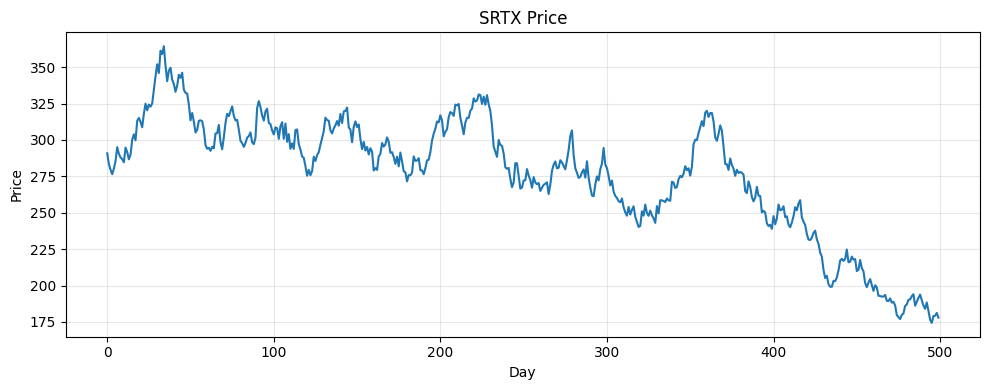

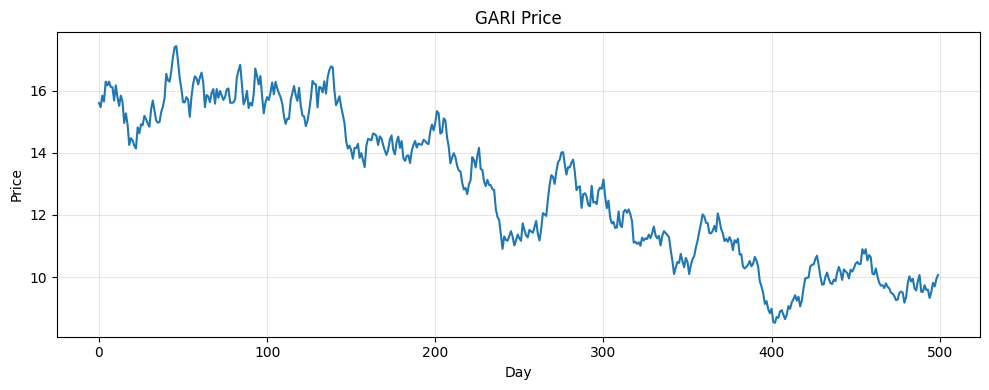

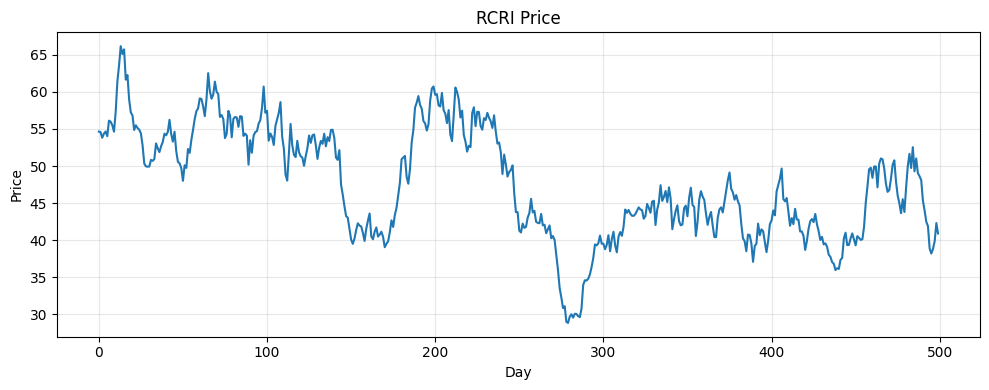

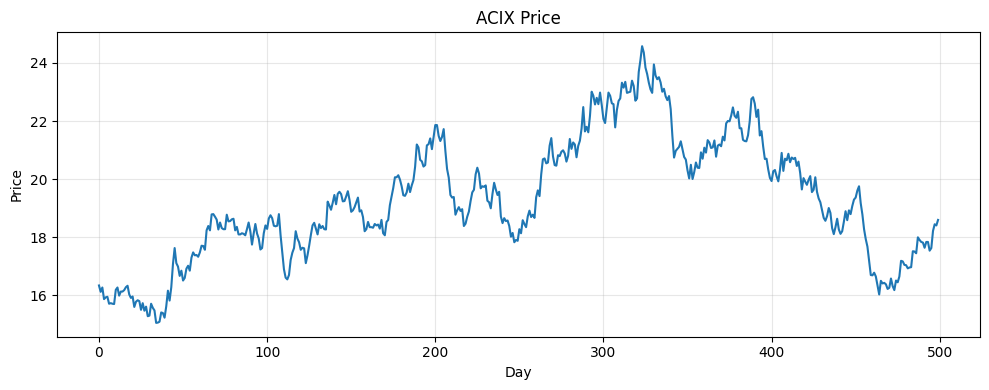

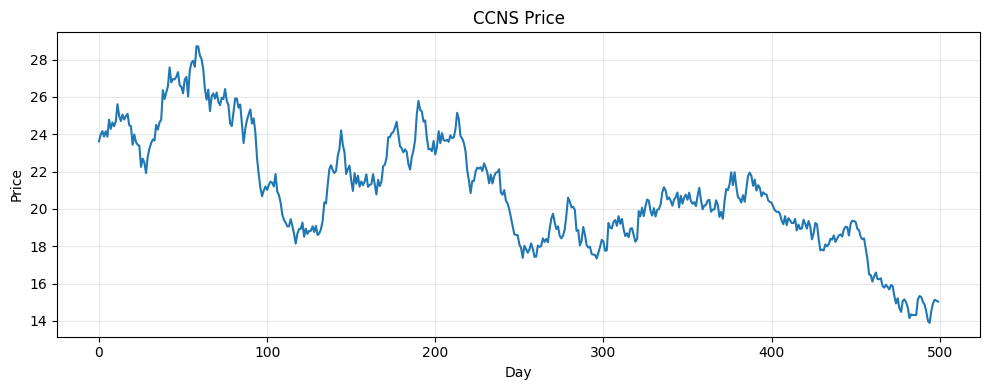

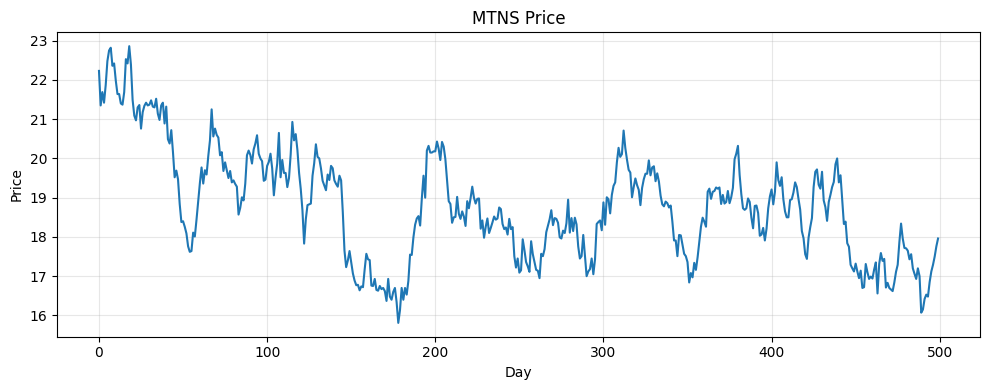

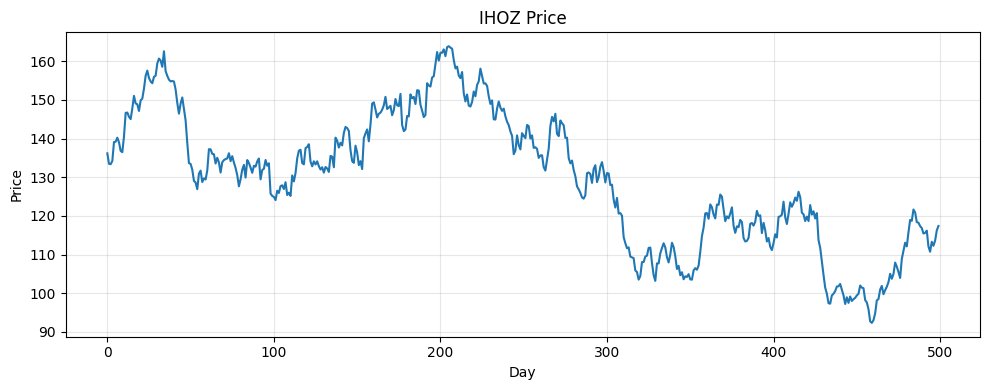

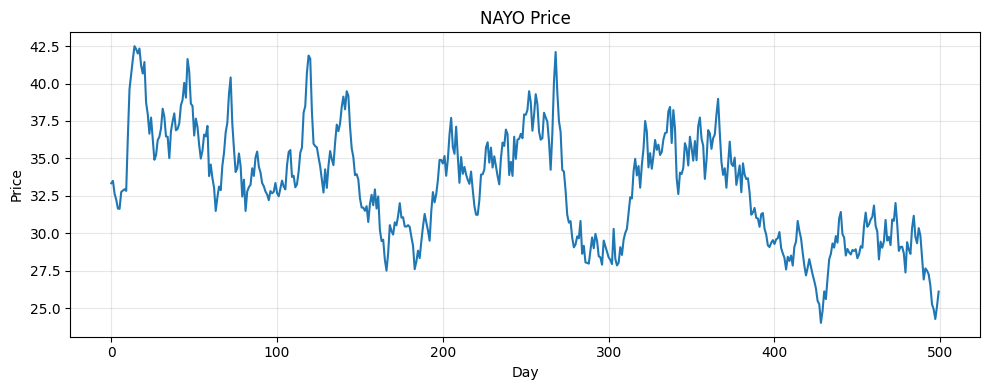

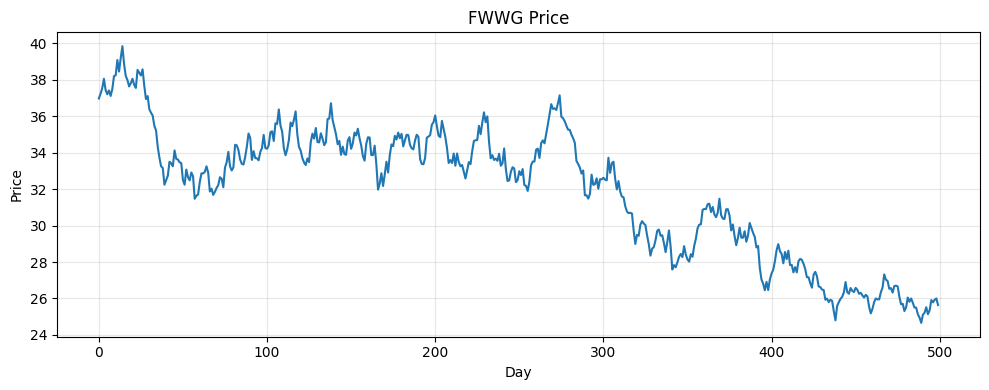

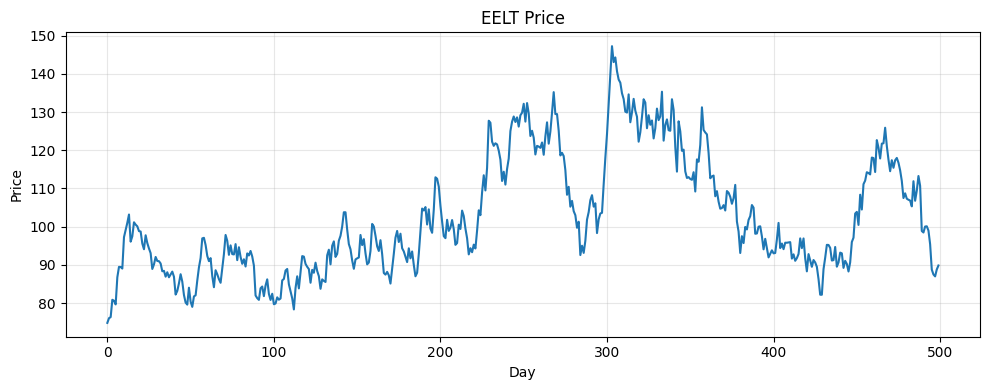

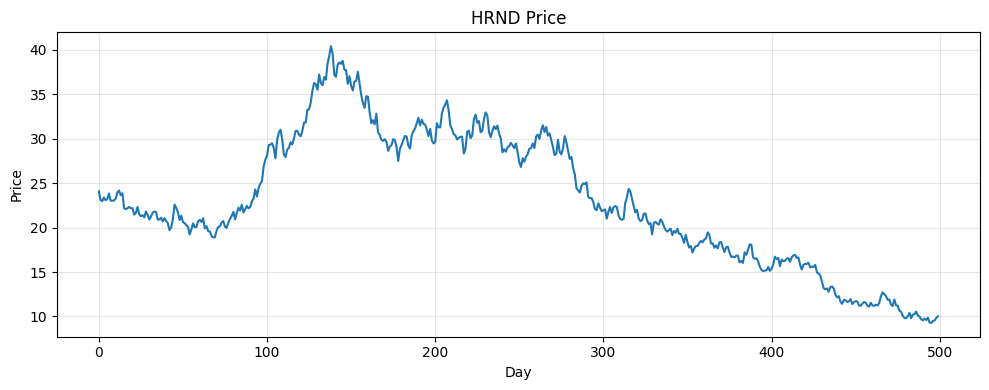

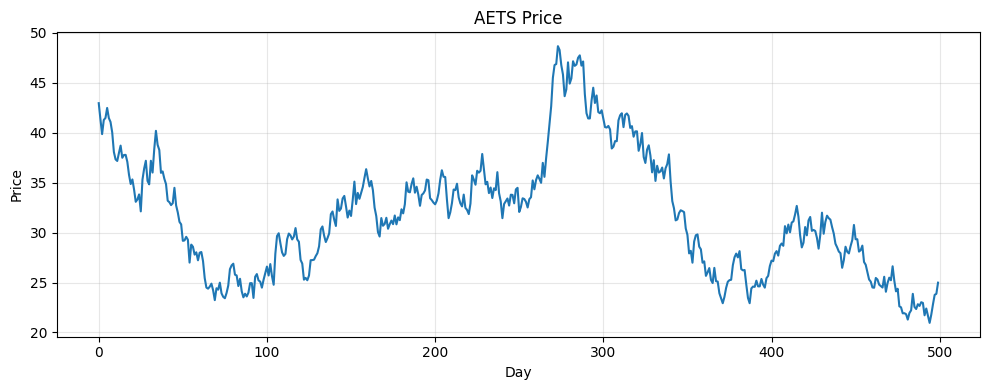

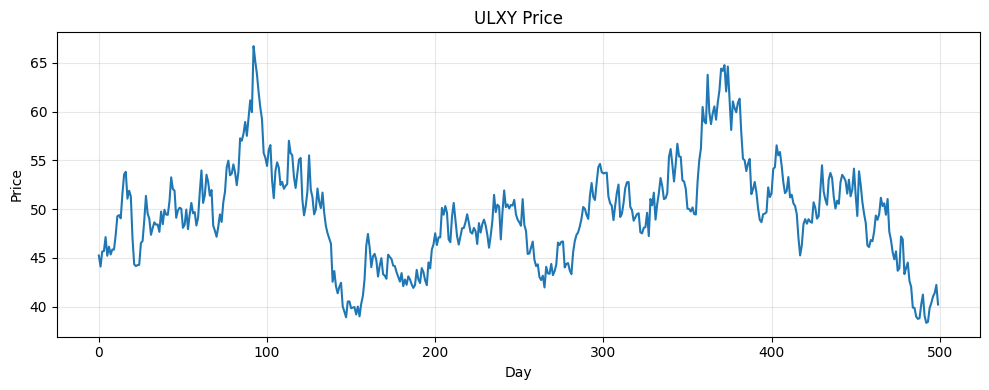

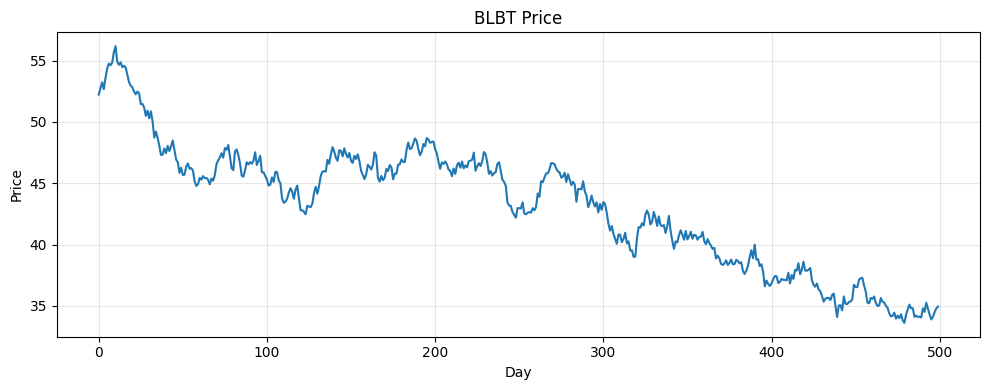

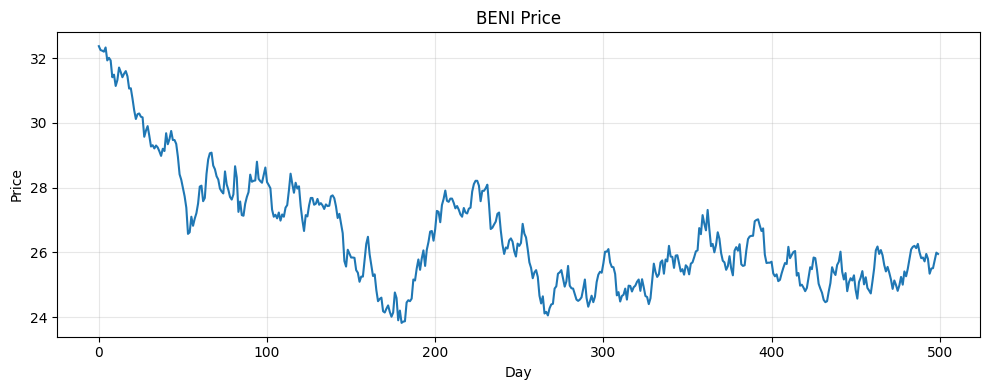

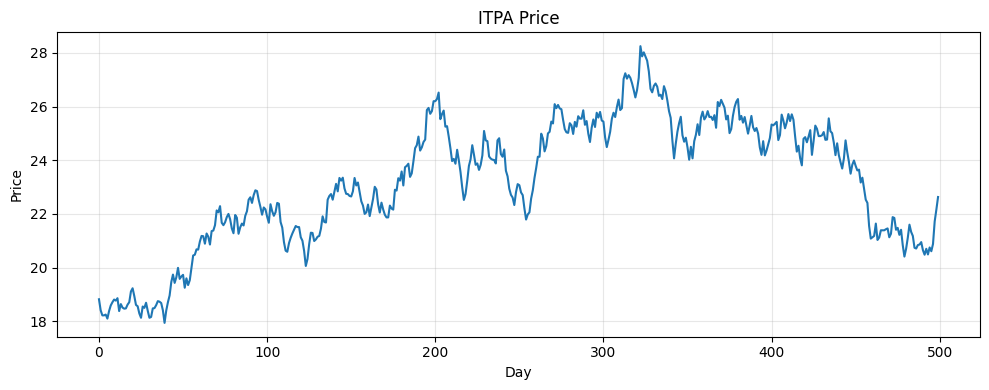

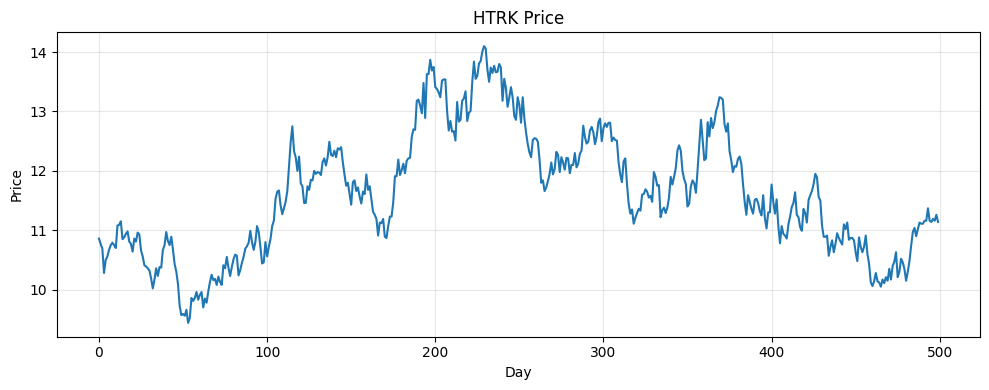

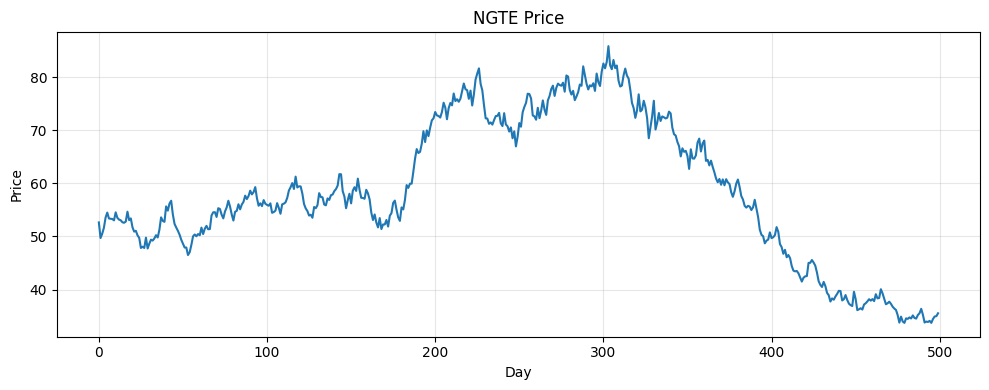

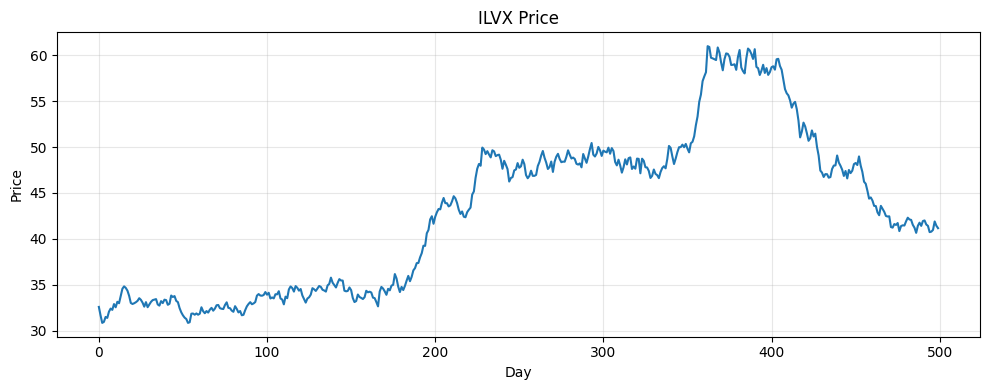

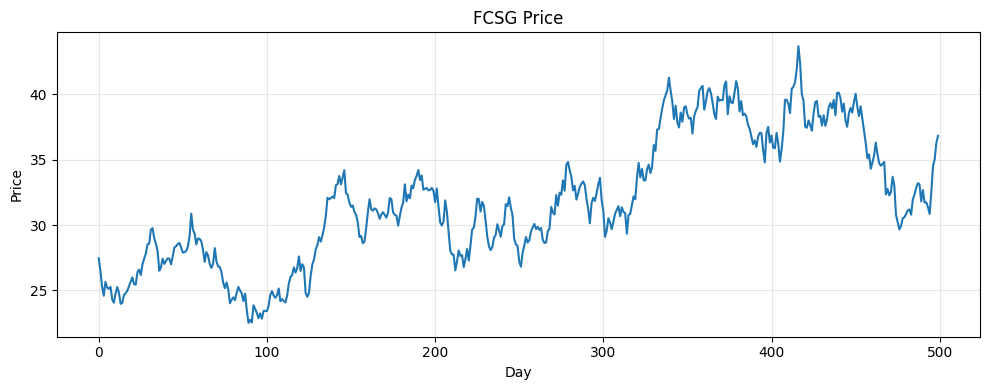

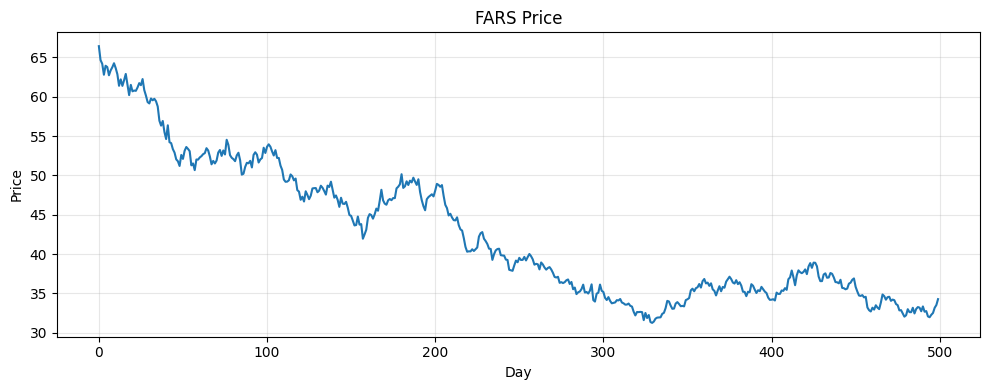

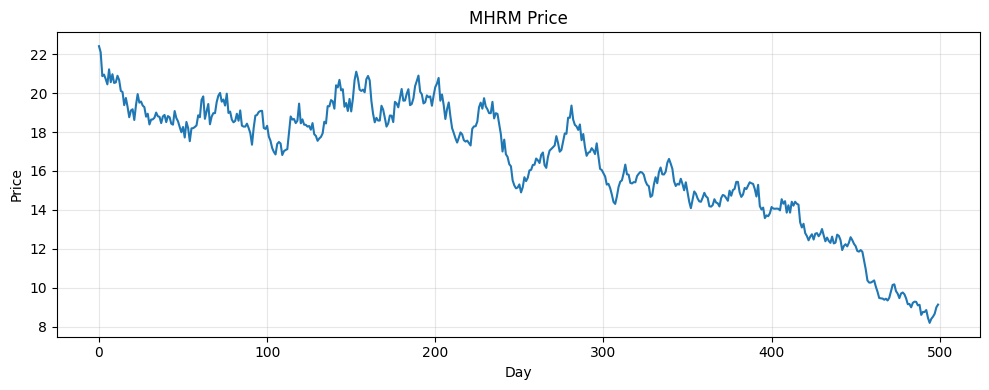

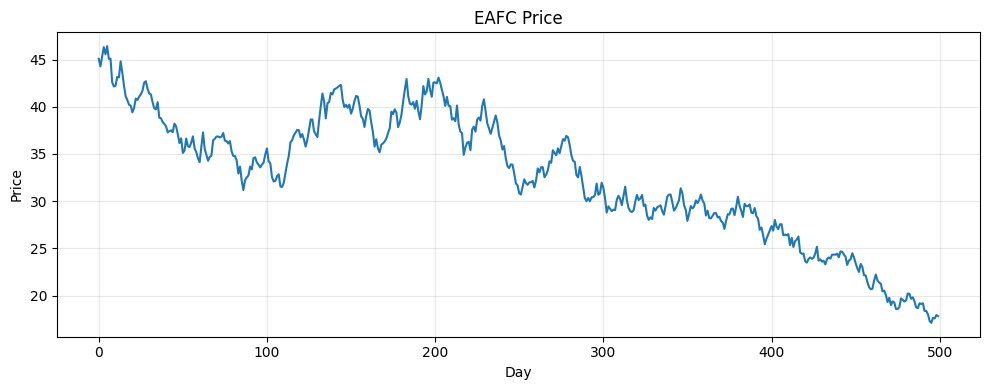

In [3]:
import matplotlib.pyplot as plt

for asset in prices.columns:
    plt.figure(figsize=(10, 4))

    plt.plot(prices.index, prices[asset])

    plt.title(f"{asset} Price")
    plt.xlabel("Day")
    plt.ylabel("Price")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Daily Volatility


In [ ]:
# Daily percentage returns
daily_returns = prices.pct_change()

# Daily volatility for each asset, expressed as a percentage
daily_volatility = daily_returns.std() * 100

# Sort so the differences are easier to see
daily_volatility = daily_volatility.sort_values()

plt.figure(figsize=(10, 14))

plt.barh(
    daily_volatility.index,
    daily_volatility.values
)

plt.title("Asset Daily Volatility")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Asset")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Daily Returns Correlation

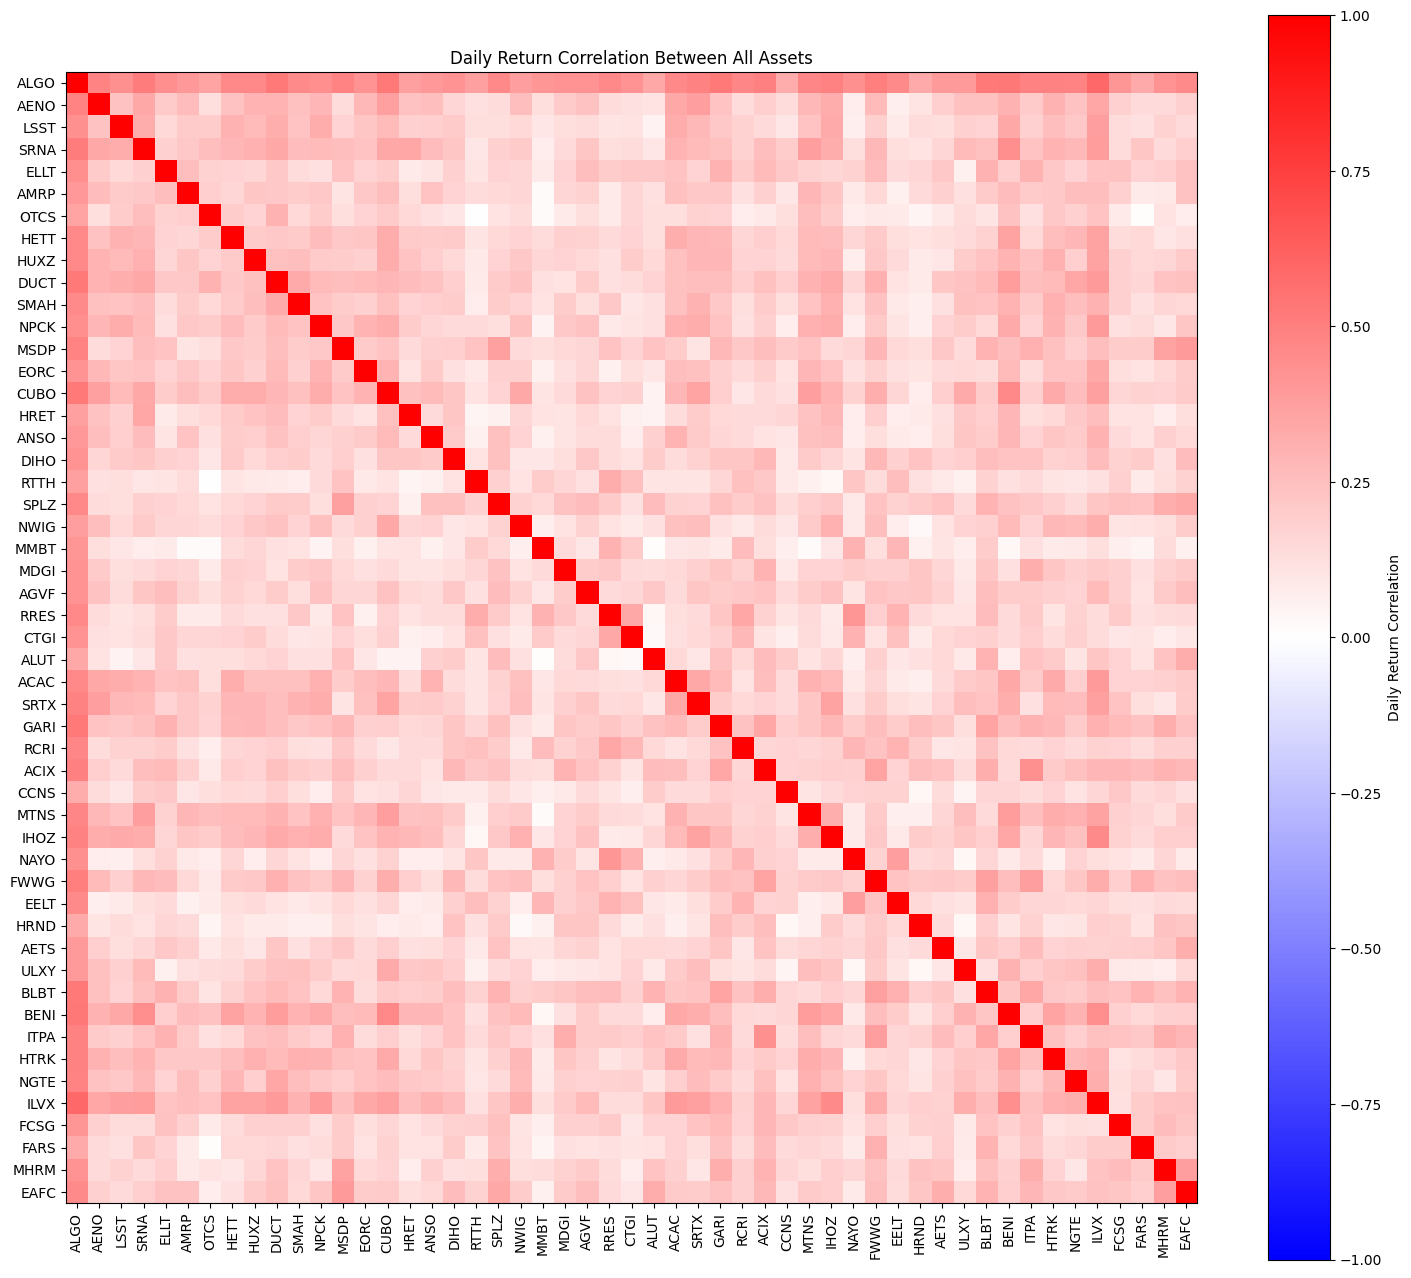

In [4]:
daily_returns = prices.pct_change()
daily_returns = daily_returns.dropna()
correlation_matrix = daily_returns.corr()
plt.figure(figsize=(15, 13))

plt.imshow(
    correlation_matrix,
    cmap="bwr",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Daily Return Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Daily Return Correlation Between All Assets")

plt.tight_layout()
plt.show()



In [5]:
import numpy as np
upper_triangle = np.triu(
    np.ones(correlation_matrix.shape),
    k=1
).astype(bool)

correlation_pairs = (
    correlation_matrix
    .where(upper_triangle)
    .stack()
    .dropna()
    .sort_values(ascending=False)
)

print("Highest daily return correlations:\n")

for (asset_1, asset_2), corr in correlation_pairs.head(10).items():
    print(f"{asset_1} - {asset_2}: {corr:.4f}")

print("Lowest daily return correlations:\n")

for (asset_1, asset_2), corr in correlation_pairs.tail(10).items():
    print(f"{asset_1} - {asset_2}: {corr:.4f}")

Highest daily return correlations:

ALGO - ILVX: 0.5908
ALGO - BENI: 0.5259
ALGO - CUBO: 0.5227
ALGO - DUCT: 0.5221
ALGO - BLBT: 0.5220
ALGO - GARI: 0.5203
ALGO - SRNA: 0.5123
ALGO - FWWG: 0.5006
ALGO - ACIX: 0.4928
ALGO - ITPA: 0.4899
Lowest daily return correlations:

HRND - ULXY: 0.0352
RRES - ALUT: 0.0327
NWIG - HRND: 0.0289
CTGI - ALUT: 0.0259
MMBT - MTNS: 0.0223
AMRP - MMBT: 0.0193
OTCS - MMBT: 0.0182
MMBT - ALUT: 0.0115
OTCS - FARS: 0.0083
OTCS - RTTH: -0.0003


ALGO correlation testing

In [ ]:
# Get ALGO's correlation with every other asset
algo_correlations = (
    correlation_matrix["ALGO"]
    .drop("ALGO")
    .sort_values(ascending=False)
)

# Print all correlations
print("ALGO daily return correlations:\n")

for asset, corr in algo_correlations.items():
    print(f"ALGO - {asset}: {corr:.4f}")

# Summary
print("\nSummary:")
print(algo_correlations.describe().round(4))

print("\nCounts above selected correlation levels:")
print(f"Above 0.5: {(algo_correlations > 0.5).sum()}")
print(f"Above 0.4: {(algo_correlations > 0.4).sum()}")
print(f"Above 0.3: {(algo_correlations > 0.3).sum()}")

# Plot all ALGO correlations
algo_correlations_sorted = algo_correlations.sort_values()

plt.figure(figsize=(10, 12))

plt.barh(
    algo_correlations_sorted.index,
    algo_correlations_sorted.values
)

plt.axvline(0, linewidth=1)
plt.title("Daily Return Correlation with ALGO")
plt.xlabel("Correlation")
plt.ylabel("Asset")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Distance Correlation

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Daily returns: 499 observations for each asset
daily_returns = prices.pct_change().dropna()

assets = daily_returns.columns
number_of_assets = len(assets)


def centred_distance_matrix(values):
    """
    Construct the double-centred pairwise distance matrix
    used in distance correlation.
    """
    values = np.asarray(values, dtype=float)

    # Distance between every pair of daily-return observations
    distances = np.abs(values[:, None] - values[None, :])

    row_means = distances.mean(axis=1, keepdims=True)
    column_means = distances.mean(axis=0, keepdims=True)
    overall_mean = distances.mean()

    return distances - row_means - column_means + overall_mean


# Calculate each asset's centred distance matrix once
centred_matrices = {}
distance_variances_squared = {}

for asset in assets:
    matrix = centred_distance_matrix(daily_returns[asset].values)

    centred_matrices[asset] = matrix
    distance_variances_squared[asset] = np.mean(matrix * matrix)


# Empty matrix in which to store all distance correlations
distance_correlation_matrix = pd.DataFrame(
    np.eye(number_of_assets),
    index=assets,
    columns=assets
)

pair_results = []

# Calculate every unique pair
for i in range(number_of_assets):
    for j in range(i + 1, number_of_assets):

        asset_1 = assets[i]
        asset_2 = assets[j]

        matrix_1 = centred_matrices[asset_1]
        matrix_2 = centred_matrices[asset_2]

        distance_covariance_squared = np.mean(matrix_1 * matrix_2)

        denominator = np.sqrt(
            distance_variances_squared[asset_1]
            * distance_variances_squared[asset_2]
        )

        if denominator > 0:
            distance_corr = np.sqrt(
                max(distance_covariance_squared, 0) / denominator
            )
        else:
            distance_corr = np.nan

        # Fill both sides of the symmetrical matrix
        distance_correlation_matrix.loc[asset_1, asset_2] = distance_corr
        distance_correlation_matrix.loc[asset_2, asset_1] = distance_corr

        pair_results.append({
            "asset_1": asset_1,
            "asset_2": asset_2,
            "distance_correlation": distance_corr
        })


# Turn all unique pairs into a ranked table
distance_correlation_pairs = (
    pd.DataFrame(pair_results)
    .sort_values("distance_correlation", ascending=False)
    .reset_index(drop=True)
)


# Heatmap
plt.figure(figsize=(15, 13))

plt.imshow(
    distance_correlation_matrix,
    vmin=0,
    vmax=1
)

plt.colorbar(label="Distance Correlation")

plt.xticks(
    range(number_of_assets),
    assets,
    rotation=90
)

plt.yticks(
    range(number_of_assets),
    assets
)

plt.title("Distance Correlation Between Daily Returns")

plt.tight_layout()
plt.show()


# Print strongest and weakest pairs
print("Highest distance correlations:\n")
print(distance_correlation_pairs.head(10).to_string(index=False))

print("\nLowest distance correlations:\n")
print(distance_correlation_pairs.tail(10).to_string(index=False))

ALGO - Linear Basket

In [ ]:
# Use daily returns rather than raw prices
daily_returns = prices.pct_change().dropna()

# ALGO is the variable we are trying to explain
y = daily_returns["ALGO"]

# The other 50 assets are the explanatory variables
X = daily_returns.drop(columns="ALGO")

# Preserve time order: first 250 returns for training
split_point = 250

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]

y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Number of explanatory assets:", X.shape[1])

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_predictions)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)

test_residuals = y_test - test_predictions

print(f"Training R²: {train_r2:.4f}")
print(f"Testing R²:  {test_r2:.4f}")

print(f"\nTraining RMSE: {train_rmse:.6f}")
print(f"Testing RMSE:  {test_rmse:.6f}")

print(f"\nALGO test volatility:    {y_test.std():.6f}")
print(f"Test residual volatility: {test_residuals.std():.6f}")

print(
    "Residual volatility as a percentage of ALGO volatility:",
    f"{100 * test_residuals.std() / y_test.std():.2f}%"
)

In [ ]:
algo_weights = pd.Series(
    model.coef_,
    index=X.columns,
    name="coefficient"
)

# Sort by coefficient magnitude
algo_weights_ranked = algo_weights.reindex(
    algo_weights.abs().sort_values(ascending=False).index
)

print(f"Intercept: {model.intercept_:.8f}")
print(f"Sum of coefficients: {algo_weights.sum():.4f}")
print(f"Positive coefficients: {(algo_weights > 0).sum()}")
print(f"Negative coefficients: {(algo_weights < 0).sum()}")

print("\nLargest coefficients by absolute value:\n")
print(algo_weights_ranked.head(15))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Actual ALGO return"
)

plt.plot(
    y_test.index,
    test_predictions,
    label="Predicted ALGO return"
)

plt.title("Actual vs Predicted ALGO Returns: Test Period")
plt.xlabel("Day")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(
    test_residuals.index,
    test_residuals
)

plt.axhline(0, linewidth=1)

plt.title("ALGO Regression Residuals: Test Period")
plt.xlabel("Day")
plt.ylabel("Actual Return - Predicted Return")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Equal-weight average return of the 50 non-ALGO assets
equal_weight_return = daily_returns.drop(
    columns="ALGO"
).mean(axis=1)

# Compare it with ALGO over the same test period
equal_weight_test = equal_weight_return.loc[y_test.index]

equal_weight_r2 = r2_score(
    y_test,
    equal_weight_test
)

equal_weight_residuals = (
    y_test - equal_weight_test
)

equal_weight_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        equal_weight_test
    )
)

print(f"Equal-weight test R²: {equal_weight_r2:.4f}")
print(f"Equal-weight test RMSE: {equal_weight_rmse:.6f}")

print(
    "Residual volatility as a percentage of ALGO volatility:",
    f"{100 * equal_weight_residuals.std() / y_test.std():.2f}%"
)

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.index,
    y_test,
    label="Actual ALGO return"
)

plt.plot(
    equal_weight_test.index,
    equal_weight_test,
    label="Equal-weight basket return"
)

plt.title("ALGO vs Equal-Weight Basket: Test Period")
plt.xlabel("Day")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## ALGO basket spread mean reversion


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ALGO daily returns
algo_returns = daily_returns["ALGO"]

# Equal-weight average return of the other 50 assets
basket_returns = (
    daily_returns
    .drop(columns="ALGO")
    .mean(axis=1)
)

# Daily ALGO return relative to the basket
tracking_error = algo_returns - basket_returns

# Accumulated log-return difference
relative_spread = (
    np.log1p(algo_returns)
    - np.log1p(basket_returns)
).cumsum()

mean_reversion_data = pd.DataFrame({
    "algo_return": algo_returns,
    "basket_return": basket_returns,
    "tracking_error": tracking_error,
    "relative_spread": relative_spread
})

mean_reversion_data.head()

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    relative_spread.index,
    relative_spread,
    label="ALGO minus basket spread"
)

plt.axhline(
    relative_spread.mean(),
    linestyle="--",
    linewidth=1,
    label="Full-sample mean"
)

plt.title("ALGO vs Equal-Weight Basket Relative Spread")
plt.xlabel("Day")
plt.ylabel("Cumulative Log-Return Difference")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
lagged_tracking_correlations = pd.Series({
    lag: tracking_error.autocorr(lag=lag)
    for lag in range(1, 11)
}, name="autocorrelation")

print("Tracking-error autocorrelation by lag:\n")
print(lagged_tracking_correlations.round(4))

plt.figure(figsize=(9, 4))

plt.bar(
    lagged_tracking_correlations.index,
    lagged_tracking_correlations.values
)

plt.axhline(0, linewidth=1)

plt.title("Tracking-Error Autocorrelation")
plt.xlabel("Lag in Days")
plt.ylabel("Autocorrelation")
plt.xticks(range(1, 11))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

regression_data = pd.DataFrame({
    "spread_change": relative_spread.diff(),
    "lagged_spread": relative_spread.shift(1)
}).dropna()

X = sm.add_constant(
    regression_data["lagged_spread"]
)

y = regression_data["spread_change"]

mean_reversion_model = sm.OLS(y, X).fit()

beta = mean_reversion_model.params["lagged_spread"]
beta_p_value = mean_reversion_model.pvalues["lagged_spread"]

phi = 1 + beta

print(f"Mean-reversion coefficient beta: {beta:.6f}")
print(f"Beta p-value: {beta_p_value:.6f}")
print(f"AR(1) coefficient phi: {phi:.6f}")

In [ ]:
if 0 < phi < 1:
    half_life = np.log(0.5) / np.log(phi)

    print(
        f"Estimated mean-reversion half-life: "
        f"{half_life:.2f} days"
    )
else:
    half_life = np.nan

    print(
        "A standard positive mean-reversion half-life "
        "cannot be calculated because phi is not between 0 and 1."
    )

In [ ]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(
    relative_spread.dropna(),
    autolag="AIC"
)

adf_statistic = adf_result[0]
adf_p_value = adf_result[1]
lags_used = adf_result[2]

print(f"ADF statistic: {adf_statistic:.4f}")
print(f"ADF p-value: {adf_p_value:.6f}")
print(f"Lags used: {lags_used}")

print("\nCritical values:")

for level, critical_value in adf_result[4].items():
    print(f"{level}: {critical_value:.4f}")

## Cointegratiom brute force

In [38]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.tsa.stattools import coint
from statsmodels.stats.multitest import multipletests


# ---------------------------------------------------------
# 1. Prepare log-price data
# ---------------------------------------------------------

price_data = prices.astype(float).copy()

if price_data.isna().any().any():
    raise ValueError("The prices DataFrame contains missing values.")

if (price_data <= 0).any().any():
    raise ValueError("All prices must be positive before taking logarithms.")

log_prices = np.log(price_data)

assets = list(log_prices.columns)
number_of_pairs = len(assets) * (len(assets) - 1) // 2

print(f"Number of assets: {len(assets)}")
print(f"Number of unique pairs: {number_of_pairs}")


# ---------------------------------------------------------
# 2. Function for estimating spread half-life
# ---------------------------------------------------------

def estimate_half_life(spread):
    """
    Estimate the mean-reversion half-life of a spread using:

        change_t = constant + lambda * spread_(t-1) + error_t

    Returns NaN when a standard positive half-life cannot be calculated.
    """

    spread = pd.Series(spread).dropna()

    regression_data = pd.DataFrame({
        "spread_change": spread.diff(),
        "lagged_spread": spread.shift(1)
    }).dropna()

    if len(regression_data) < 20:
        return np.nan

    X = sm.add_constant(regression_data["lagged_spread"])
    y = regression_data["spread_change"]

    model = sm.OLS(y, X).fit()

    mean_reversion_coefficient = model.params["lagged_spread"]
    phi = 1 + mean_reversion_coefficient

    if 0 < phi < 1:
        return np.log(0.5) / np.log(phi)

    return np.nan


# ---------------------------------------------------------
# 3. Brute-force every unique asset pair
# ---------------------------------------------------------

results = []

for i in range(len(assets)):
    for j in range(i + 1, len(assets)):

        asset_1 = assets[i]
        asset_2 = assets[j]

        series_1 = log_prices[asset_1]
        series_2 = log_prices[asset_2]

        try:
            # Direction 1:
            # asset_1 = alpha + beta * asset_2 + residual
            statistic_1_on_2, p_value_1_on_2, _ = coint(
                series_1,
                series_2,
                trend="c",
                autolag="aic"
            )

            # Direction 2:
            # asset_2 = alpha + beta * asset_1 + residual
            statistic_2_on_1, p_value_2_on_1, _ = coint(
                series_2,
                series_1,
                trend="c",
                autolag="aic"
            )

            # Conservative pair-level score:
            # both directions need to look convincing
            robust_p_value = max(
                p_value_1_on_2,
                p_value_2_on_1
            )

            # Use the better direction to construct the candidate spread
            if p_value_1_on_2 <= p_value_2_on_1:
                dependent_asset = asset_1
                hedge_asset = asset_2

                dependent_series = series_1
                hedge_series = series_2

                selected_p_value = p_value_1_on_2
                selected_test_statistic = statistic_1_on_2

            else:
                dependent_asset = asset_2
                hedge_asset = asset_1

                dependent_series = series_2
                hedge_series = series_1

                selected_p_value = p_value_2_on_1
                selected_test_statistic = statistic_2_on_1

            # Estimate the chosen log-price relationship
            X = sm.add_constant(hedge_series)
            relationship_model = sm.OLS(
                dependent_series,
                X
            ).fit()

            intercept = relationship_model.params["const"]
            hedge_ratio = relationship_model.params[hedge_asset]

            # Fitted residual spread
            spread = (
                dependent_series
                - intercept
                - hedge_ratio * hedge_series
            )

            half_life = estimate_half_life(spread)

            results.append({
                "asset_1": asset_1,
                "asset_2": asset_2,

                "p_value_asset_1_on_asset_2": p_value_1_on_2,
                "p_value_asset_2_on_asset_1": p_value_2_on_1,

                "robust_p_value": robust_p_value,
                "best_direction_p_value": selected_p_value,
                "test_statistic": selected_test_statistic,

                "dependent_asset": dependent_asset,
                "hedge_asset": hedge_asset,

                "intercept": intercept,
                "hedge_ratio": hedge_ratio,

                "spread_mean": spread.mean(),
                "spread_std": spread.std(),
                "half_life_days": half_life
            })

        except Exception as error:
            print(
                f"Could not test {asset_1} - {asset_2}: {error}"
            )


# ---------------------------------------------------------
# 4. Create the ranked results table
# ---------------------------------------------------------

cointegration_results = pd.DataFrame(results)

cointegration_results = cointegration_results.sort_values(
    "robust_p_value",
    ascending=True
).reset_index(drop=True)


# ---------------------------------------------------------
# 5. Correct for testing 1,275 different pairs
# ---------------------------------------------------------

number_of_completed_tests = len(cointegration_results)

bonferroni_threshold = 0.05 / number_of_completed_tests

cointegration_results["raw_significant_5_percent"] = (
    cointegration_results["robust_p_value"] < 0.05
)

cointegration_results["bonferroni_significant"] = (
    cointegration_results["robust_p_value"]
    < bonferroni_threshold
)

fdr_reject, fdr_adjusted_p_values, _, _ = multipletests(
    cointegration_results["robust_p_value"],
    alpha=0.05,
    method="fdr_bh"
)

cointegration_results["fdr_significant"] = fdr_reject
cointegration_results["fdr_adjusted_p_value"] = (
    fdr_adjusted_p_values
)


# ---------------------------------------------------------
# 6. Print summary results
# ---------------------------------------------------------

print("\nCointegration screening summary:\n")

print(
    f"Pairs successfully tested: "
    f"{number_of_completed_tests}"
)

print(
    f"Pairs with raw robust p-value below 0.05: "
    f"{cointegration_results['raw_significant_5_percent'].sum()}"
)

print(
    f"Bonferroni threshold: "
    f"{bonferroni_threshold:.8f}"
)

print(
    f"Pairs significant after Bonferroni correction: "
    f"{cointegration_results['bonferroni_significant'].sum()}"
)

print(
    f"Pairs significant after 5% FDR correction: "
    f"{cointegration_results['fdr_significant'].sum()}"
)


# ---------------------------------------------------------
# 7. Print the strongest candidates
# ---------------------------------------------------------

columns_to_show = [
    "asset_1",
    "asset_2",
    "robust_p_value",
    "fdr_adjusted_p_value",
    "fdr_significant",
    "dependent_asset",
    "hedge_asset",
    "hedge_ratio",
    "half_life_days"
]

print("\nStrongest pairwise cointegration candidates:\n")

print(
    cointegration_results[
        columns_to_show
    ]
    .head(20)
    .to_string(
        index=False,
        float_format=lambda value: f"{value:.6f}"
    )
)


# ---------------------------------------------------------
# 8. Store significant candidates separately
# ---------------------------------------------------------

cointegration_candidates = (
    cointegration_results[
        cointegration_results["fdr_significant"]
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"\nSaved {len(cointegration_candidates)} "
    f"FDR-significant candidates in "
    f"'cointegration_candidates'."
)

print(
    "All ranked pair results are stored in "
    "'cointegration_results'."
)

Number of assets: 51
Number of unique pairs: 1275

Cointegration screening summary:

Pairs successfully tested: 1275
Pairs with raw robust p-value below 0.05: 43
Bonferroni threshold: 0.00003922
Pairs significant after Bonferroni correction: 4
Pairs significant after 5% FDR correction: 7

Strongest pairwise cointegration candidates:

asset_1 asset_2  robust_p_value  fdr_adjusted_p_value  fdr_significant dependent_asset hedge_asset  hedge_ratio  half_life_days
   SMAH    ILVX        0.000003              0.002658             True            SMAH        ILVX     1.031074        4.844421
   AENO    NWIG        0.000004              0.002658             True            NWIG        AENO     0.993250        3.712272
   EORC    NGTE        0.000007              0.003102             True            NGTE        EORC     0.941529        5.021822
   HUXZ    ACAC        0.000016              0.005055             True            HUXZ        ACAC     1.020139        5.624832
   MHRM    EAFC        0